<a href="https://colab.research.google.com/github/jerry44168914jerry-code/DL/blob/main/20250714DL-HandwritingRecognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
#解壓縮Mnixt的資料夾

import sys
import gzip
import os


zipped_mnist = [i for i in os.listdir() if i.endswith('ubyte.gz')]
for j in zipped_mnist:
  with gzip.GzipFile(j, mode='rb') as decompressed, open(j[:-3], 'wb') as outfile:
    outfile.write(decompressed.read())

In [9]:
#讀取Mnist的檔案

import numpy as np
import struct

def load_mnist(path, kind='train'):
  images_path = os.path.join(path, '%s-images-idx3-ubyte' % kind)
  labels_path = os.path.join(path, '%s-labels-idx1-ubyte' % kind)

  with open(labels_path, 'rb') as lbpath:
    magic, n = struct.unpack('>II', lbpath.read(8))
    labels = np.fromfile(lbpath, dtype=np.uint8)

  with open(images_path, 'rb') as imgpath:
    magic, num, rows, cols = struct.unpack('>IIII', imgpath.read(16))
    images = np.fromfile(imgpath, dtype=np.uint8).reshape(len(labels), 784)
    images = ((images/ 255) -0.5) * 2

  return images, labels

# 讀取檔案
X_train, y_train = load_mnist('', kind='train')
print('Rows: %d, columns: %d' % (X_train.shape[0], X_train.shape[1]))
print('Rows: %d' % (y_train.shape[0]))

X_test, y_test = load_mnist('', kind='t10k')
print('Rows: %d, columns: %d' % (X_test.shape[0], X_test.shape[1]))
print('Rows: %d' % (y_test.shape[0]))

Rows: 60000, columns: 784
Rows: 60000
Rows: 10000, columns: 784
Rows: 10000


# **3.顯示手寫數字的圖片**

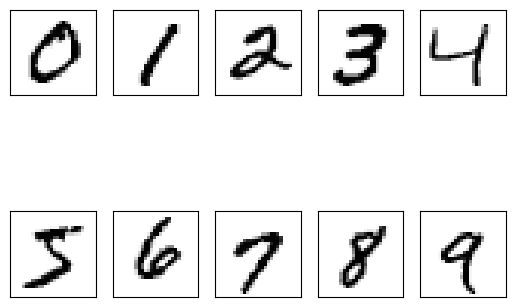

In [10]:
# 顯示手寫數字的圖片

import matplotlib.pyplot as plt


fig, ax = plt.subplots(nrows=2, ncols=5, sharex=True, sharey=True)
ax = ax.flatten()
for i in range(10):
  img = X_train[y_train == i][0].reshape(28, 28)
  ax[i].imshow(img, cmap='Greys')

ax[0].set_xticks([])
ax[0].set_yticks([])
plt.show()

# **4.顯示單一數字不同的各種手寫樣態**

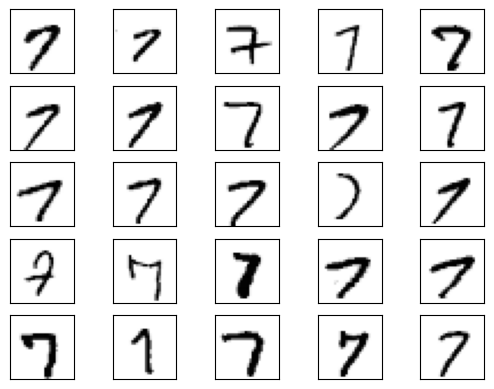

In [11]:
# 顯示手寫數字的圖片

import matplotlib.pyplot as plt


fig, ax = plt.subplots(nrows=5, ncols=5, sharex=True, sharey=True)
ax = ax.flatten()
for i in range(25):
  img = X_train[y_train == 7][i].reshape(28, 28)
  ax[i].imshow(img, cmap='Greys')

ax[0].set_xticks([])
ax[0].set_yticks([])
plt.show()

# **5.使用Python實作多層感知器演算法**

In [12]:
from re import S
class NeuroetMLP(object):
  def __init__(self, n_hidden = 30, l2 = 0.0, epochs = 100, eta = 0.001, shuffle=True, minibatch_size = 1, seed = None):
    self.random = np.random.RandomState(seed)
    self.n_hidden = n_hidden
    self.l2 = l2
    self.epochs = epochs
    self.eta = eta
    self.shuffle = shuffle
    self.minibatch_size = minibatch_size

  def onehot(self, y, n_classes):
    onehot = np.zeros((n_classes, y.shape[0]))
    for idx, val in enumerate(y.astype(int)):
      onehot[val, idx] = 1.0
    return onehot.T

  def sigmoid(self, z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -250, 250)))

  def forward(self, X):
    z_h = np.dot(X, self.w_h) + self.b_h
    a_h = self.sigmoid(z_h)
    z_out = np.dot(a_h, self.w_out) + self.b_out
    a_out = self.sigmoid(z_out)
    return z_h, a_h, z_out, a_out

  def compute_cost(self, y_enc, output):
    L2_term = self.l2 * (np.sum(self.w_h ** 2.0) + np.sum(self.w_out) ** 2.0)
    term1 = -y_enc * np.log(output)
    term2 = (1.0 - y_enc) * np.log(1.0 - output)
    cost = np.sum(term1 - term2) + L2_term
    return cost

  def predict(self, X):
    z_h, a_h, z_out, a_out = self.forward(X)
    y_pred = np.argmax(z_out, axis=1)
    return y_pred

  def fit(self, X_train, y_train, X_test, y_test):
    n_output = np.unique(y_train).shape[0]
    n_features = X_train.shape[1]

    self.b_h = np.zeros(self.n_hidden)
    self.w_h = self.random.normal(loc=0.0, scale=0.1, size=(n_features, self.n_hidden))

    self.b_out = np.zeros(n_output)
    self.w_out = self.random.normal(loc=0.0, scale=0.1, size=(self.n_hidden, n_output))

    epoch_strlen = len(str(self.epochs))
    self.eval_ = {'cost': [], 'train_acc': [], 'test_acc': []}

    y_train_enc = self.onehot(y_train, n_output)

    for i in range(self.epochs):
      indics = np.arange(X_train.shape[0])
      if self.shuffle:
        self.random.shuffle(indics)

      for start_idx in range(0, indics.shape[0] - self.minibatch_size + 1, self.minibatch_size):
        batch_idx = indics[start_idx:start_idx + self.minibatch_size]
        z_h, a_h, z_out, a_out = self.forward(X_train[batch_idx])
        delta_out = a_out - y_train_enc[batch_idx]
        sigmoid_h = a_h * (1.0 - a_h)
        delta_h = (np.dot(delta_out, self.w_out.T) * sigmoid_h)
        grad_w_h = np.dot(X_train[batch_idx].T, delta_h)
        grad_b_h = np.sum(delta_h, axis=0)

        grad_w_out = np.dot(a_h.T, delta_out)
        grad_b_out = np.sum(delta_out, axis=0)

        delta_w_h = grad_w_h + self.l2 * self.w_h
        delta_b_h = grad_b_h
        self.w_h -= self.eta * delta_w_h
        self.b_h -= self.eta * delta_b_h

        delta_w_out = grad_w_out + self.l2 * self.w_out
        delta_b_out = grad_b_out
        self.w_out -= self.eta * delta_w_out
        self.b_out -= self.eta * delta_b_out

      z_h, a_h, z_out, a_out = self.forward(X_train)
      cost = self.compute_cost(y_enc=y_train_enc, output=a_out)

      y_train_pred = self.predict(X_train)
      y_test_pred = self.predict(X_test)
      train_acc = np.sum(y_train == y_train_pred).astype(float) / X_train.shape[0]
      test_acc = np.sum(y_test == y_test_pred).astype(float) / X_test.shape[0]

      sys.stderr.write('\r%0*d/%d | Cost: %.2f ' '| Train/Test Acc: %.2f%%/%.2f%%' % (epoch_strlen, i+1, self.epochs, cost, train_acc * 100, test_acc * 100))
      sys.stderr.flush()
      self.eval_['cost'].append(cost)
      self.eval_['train_acc'].append(train_acc)
      self.eval_['test_acc'].append(test_acc)
    return self

nn = NeuroetMLP(n_hidden=100, l2=0.01, epochs=100, eta=0.0005, minibatch_size=100, shuffle=True, seed=1)
nn.fit(X_train=X_train[:55000], y_train=y_train[:55000], X_test=X_train[55000:], y_test=y_train[55000:])

100/100 | Cost: 8122.94 | Train/Test Acc: 98.47%/97.78%

# **6.畫出模型收斂圖**

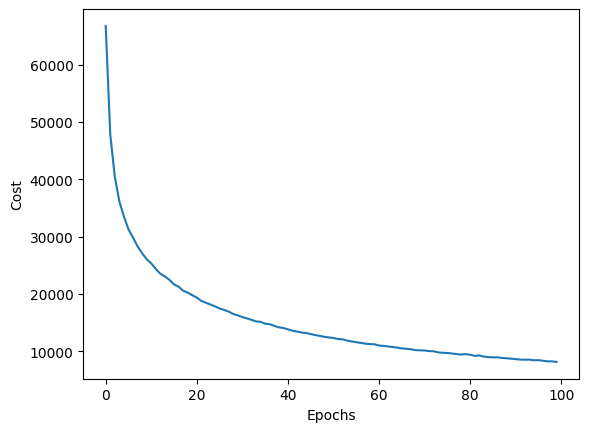

In [13]:
plt.plot(range(nn.epochs), nn.eval_['cost'])
plt.ylabel('Cost')
plt.xlabel('Epochs')
plt.show()


# **7.畫出模型準確度**

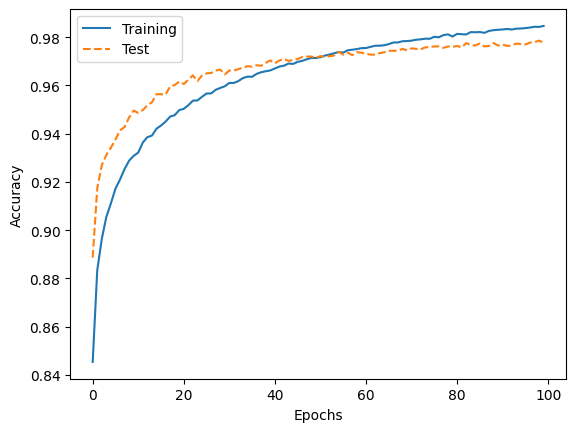

Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%Test accuracy: 0.97%

In [14]:
plt.plot(range(nn.epochs), nn.eval_['train_acc'], label='Training')
plt.plot(range(nn.epochs), nn.eval_['test_acc'], label='Test', linestyle='--')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend()
plt.show()

y_test_pred = nn.predict(X_test)
acc = np.sum(y_test == y_test_pred).astype(float) / X_test.shape[0]
print('Test accuracy: %.2f%%' % acc * 100)